# Isolation Forest baseline

First model and the baseline to beat. It's a classical anomaly detection method so no training loop, just fit it on the empty windows and score the test set. If the Transformer later can't beat this then that's already a result worth writing about.

Quick idea of how it works: it randomly cuts the feature space with straight lines until every point is alone. Normal points sit in crowded areas so they need many cuts, anomalies sit alone so they get isolated fast. Number of cuts = anomaly score.

## Load the prepared data

These come from notebook 1. Windows are raw (not normalized) so each model can normalize its own way.

In [2]:
import numpy as np 

data = np.load('../data/prepared.npz')
X_train = data['X_train']
X_val   = data['X_val']
X_test  = data['X_test']
y_test  = data['y_test']

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("test empty:", (y_test==0).sum(), " test occupied:", (y_test==1).sum())

X_train: (2105, 30, 2)
X_val: (451, 30, 2)
X_test: (1551, 30, 2)
test empty: 452  test occupied: 1099


## Make features from each window

Isolation Forest can't take a 30x2 window, it needs a flat feature vector per window. Instead of just flattening the raw 60 numbers I compute summary stats for each signal (mean, std, min, max, range). That's more meaningful and easier to explain later. 2 signals x 5 stats = 10 features per window.

In [3]:
def window_features(windows):
    feats = []
    for w in windows:          # w is (30, 2)
        f = []
        for s in range(w.shape[1]):   # each signal
            sig = w[:, s]
            f += [sig.mean(), sig.std(), sig.min(), sig.max(), sig.max()-sig.min()]
        feats.append(f)
    return np.array(feats)

F_train = window_features(X_train)
F_val   = window_features(X_val)
F_test  = window_features(X_test)

print("F_train:", F_train.shape)
print("F_test:", F_test.shape)

F_train: (2105, 10)
F_test: (1551, 10)


## Normalize the features

Same rule as before, stats from train only then apply to val and test.

In [4]:
f_mean = F_train.mean(axis=0)
f_std  = F_train.std(axis=0)

F_train_n = (F_train - f_mean) / (f_std + 1e-8)
F_val_n   = (F_val   - f_mean) / (f_std + 1e-8)
F_test_n  = (F_test  - f_mean) / (f_std + 1e-8)

print(F_train_n.shape, F_val_n.shape, F_test_n.shape)

(2105, 10) (451, 10) (1551, 10)


## Fit Isolation Forest

Fit on empty windows only (train). contamination is set low since train is all normal. Then I get anomaly scores. sklearn's score_samples gives higher = more normal, so I flip the sign to get higher = more anomalous which is easier to think about.

In [5]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
iso.fit(F_train_n)

# higher score = more anomalous
val_scores  = -iso.score_samples(F_val_n)
test_scores = -iso.score_samples(F_test_n)

print("val score range:", val_scores.min(), "to", val_scores.max())
print("test score range:", test_scores.min(), "to", test_scores.max())

val score range: 0.3276632676238329 to 0.7193114186439752
test score range: 0.3686133281321996 to 0.8229524480752726


## Pick a threshold from validation

Val is all empty (normal) so its scores tell me what normal looks like. I set the threshold high enough that almost no normal window is flagged. Using the 95th percentile of val scores, anything above that on test is called occupied.

In [6]:
threshold = np.percentile(val_scores, 95)
print("threshold:", threshold)

y_pred = (test_scores > threshold).astype(int)
print("predicted occupied:", y_pred.sum(), "out of", len(y_pred))

threshold: 0.6958313254616774
predicted occupied: 973 out of 1551


## Evaluate

Standard metrics. Precision = of the windows I flagged how many were really occupied. Recall = of the real occupied windows how many I caught. ROC-AUC uses the raw scores so it doesn't depend on the threshold.

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, test_scores)

print("precision:", round(prec, 3))
print("recall:   ", round(rec, 3))
print("f1:       ", round(f1, 3))
print("roc-auc:  ", round(auc, 3))
print("\nconfusion matrix:")
print(confusion_matrix(y_test, y_pred))

precision: 0.953
recall:    0.843
f1:        0.895
roc-auc:   0.928

confusion matrix:
[[406  46]
 [172 927]]


## Plot the score distributions

Want to see if empty and occupied windows actually separate in score. If the two distributions overlap a lot the method struggles, if they're apart it works well.

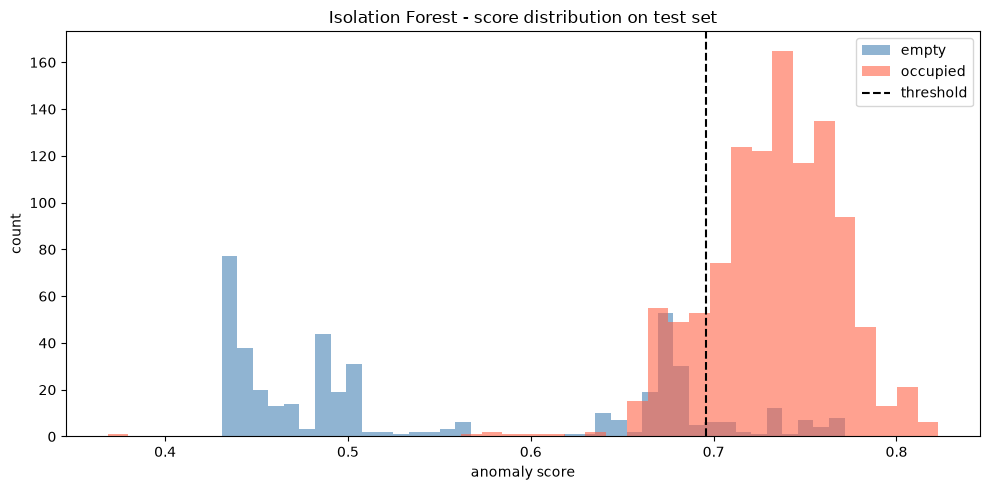

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(test_scores[y_test==0], bins=40, alpha=0.6, label='empty', color='steelblue')
plt.hist(test_scores[y_test==1], bins=40, alpha=0.6, label='occupied', color='tomato')
plt.axvline(threshold, color='black', linestyle='--', label='threshold')
plt.xlabel('anomaly score')
plt.ylabel('count')
plt.title('Isolation Forest - score distribution on test set')
plt.legend()
plt.tight_layout()
plt.savefig('../results/02_isoforest_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## Save the scores

Saving the test scores so I can compare all three models on one ROC plot later.

In [9]:
np.savez('../results/iso_scores.npz', test_scores=test_scores, y_test=y_test)
print("saved")

saved


## Results

| metric | value |
|--------|-------|
| precision | 0.953 |
| recall | 0.843 |
| f1 | 0.895 |
| roc-auc | 0.928 |

confusion matrix: [[406 46] [172 927]] -> empty: 406 correct / 46 false alarms, occupied: 172 missed / 927 caught

Pretty strong for a baseline. Precision is high (0.95) so when it flags occupied it's almost always right, few false alarms. Recall is lower (0.84) meaning it misses some occupied windows. Looking at the score plot the two classes separate clearly, the overlap is around 0.65-0.70 and that's where the mistakes happen, mostly occupied windows that score just under the threshold which is why recall drops. ROC-AUC of 0.928 is threshold independent and confirms the scores separate the classes well.

## Notebook 2 summary

Built the Isolation Forest baseline. Loaded the prepared windows from notebook 1, turned each 30x2 window into 10 summary features (mean, std, min, max, range per signal), normalized using train stats only, fit Isolation Forest on empty windows, picked the threshold from the 95th percentile of validation scores, evaluated on the mixed test set and saved the scores for the final comparison.

This is the number the MLP autoencoder and the Transformer have to beat. f1 0.895 and auc 0.928 is a solid bar so the deep models need to actually earn their place.